(247556308,)

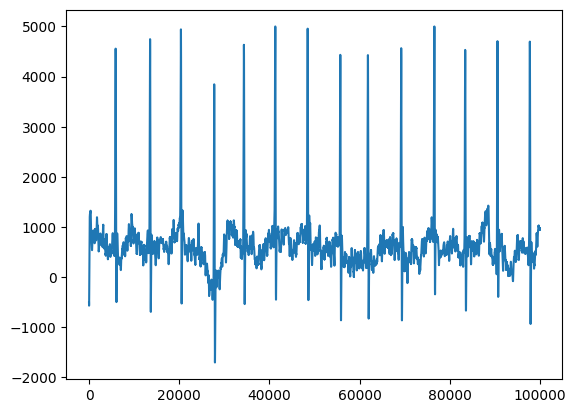

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.signal import find_peaks

folder = Path(r'C:\Users\bjmiao\The Augustine Lab Dropbox\Benjie Miao\Benjie_Jonny\SSA_Benjie\DPcachedata\iso\14T_5378529_AP_Amy_Day2_g0')
ecg_file = folder / 'nidq_ECG.npy'
ecg = np.load(ecg_file)
plt.plot(ecg[:100000])
ecg.shape


In [94]:
import sys
sys.path.insert(0, '../AugusLabDP/utils')
from importlib import reload
import ecg_utils
reload(ecg_utils)


<module 'ecg_utils' from 'e:\\Projects\\SSA\\ECGanaly\\../AugusLabDP/utils\\ecg_utils.py'>

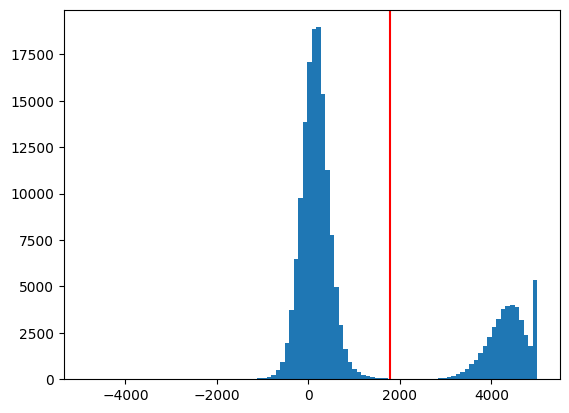

In [93]:

from ecg_utils import find_r_peaks

sampling_rate = 42372.8
r_peaks_in_seconds, threshold = find_r_peaks(ecg, sampling_rate)
peaks = find_peaks(ecg, distance=1000)[0]
plt.hist(ecg[peaks], bins = 100)
plt.axvline(threshold, color='red')


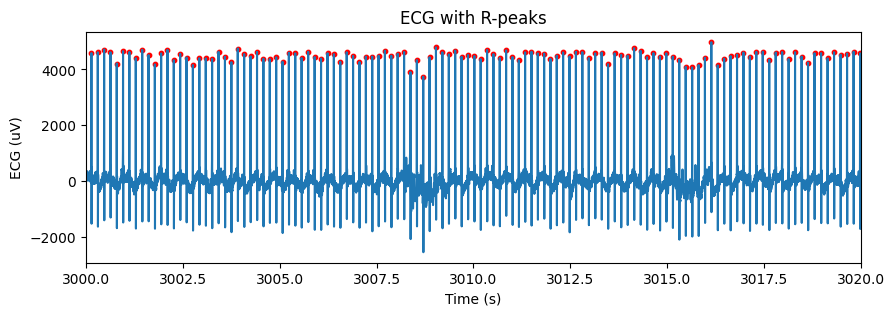

In [76]:
from ecg_utils import plot_ecg_with_r_peaks
fig, ax = plot_ecg_with_r_peaks(ecg, r_peaks_in_seconds, 3000, 3020, sampling_rate)

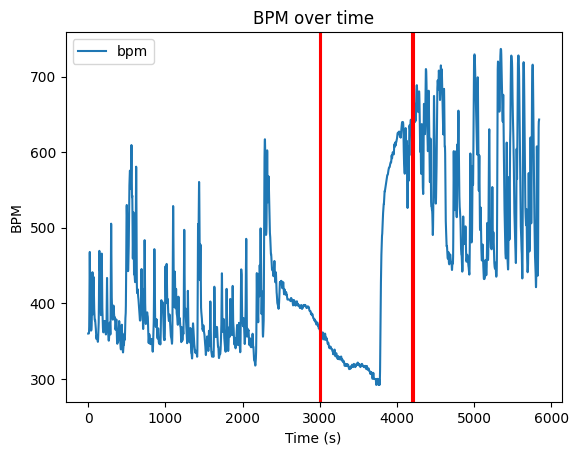

In [96]:
niSampRate = 42372.8
total_time = len(ecg) / niSampRate
from ecg_utils import get_heart_rate
bpm = get_heart_rate(r_peaks_in_seconds, total_time, timebin = 1, temporal_smoothing_window = 3)
plt.plot(bpm, label='bpm')
plt.xlabel('Time (s)')
plt.ylabel('BPM')
plt.title('BPM over time')
plt.axvline(3000, color='red')
plt.axvline(3020, color='red')
plt.axvline(4200, color='red')
plt.axvline(4220, color='red')
plt.legend()
plt.show()




In [ ]:
sys.path.insert(0, '../AugusLabDPutils')
import readout_utils
reload(readout_utils)

from readout_utils import load_dataset, get_all_probe_mapping


In [116]:
session_name = "15T_5384003B_AP_Amy_Day2_g0"
dataset = 'iso'
session_type = 'iso_day2'

data_folder = Path(r"C:\Users\bjmiao\The Augustine Lab Dropbox\Benjie Miao\Benjie_Jonny\SSA_Benjie\DPcachedata")
df_probe_mapping = get_all_probe_mapping(data_folder)
df = df_probe_mapping[dataset]
df = df[df.session == session_name]
probe_mapping = {probe:probenum for probe, probenum in zip(df['probe'], df['probenum'])}

results = load_dataset(data_folder / dataset, session_name, session_type, probe='all', probe_mapping = probe_mapping)
results.keys()

dict_keys(['has_ttl_meta', 'ttl_meta', 'has_ttl_camera', 'ttl_camera', 'session_start_time', 'session_stop_time', 'has_ttl_button', 'ttl_button', 'experimental_label_tag', 'depth_table', 'spike_matrix', 'cluster_region', 'has_cluster_region', 'has_spike', 'has_video', 'video_motSVD', 'video_motion', 'eeg', 'ecg'])

In [119]:
start, stop = results['session_start_time'], results['session_stop_time']
print(stop - start)
print(results['ttl_camera'].shape)
print(results['ttl_button'].shape)
print(results['spike_matrix'].shape)
print(results['ecg'].shape)
print(results['eeg'].shape)


5394.123022316202
(228564096,)
(230389272,)
(53941, 590)
(228564096,)
(228564096,)


In [130]:
ecg = results['ecg']
total_time = results['session_stop_time'] - results['session_start_time']
r_peaks_in_seconds, threshold = find_r_peaks(ecg, sampling_rate)
bpm = get_heart_rate(r_peaks_in_seconds, total_time, timebin = 1, temporal_smoothing_window = 5)


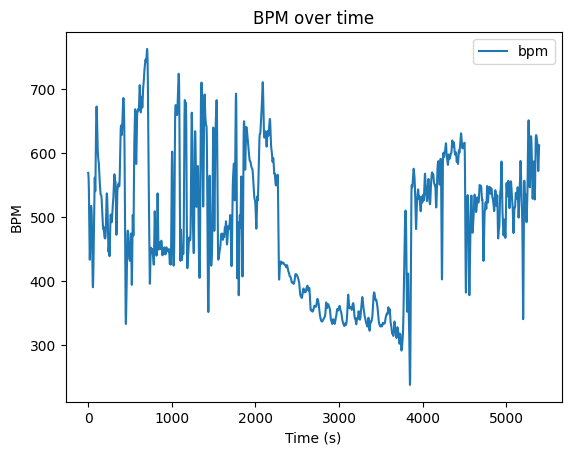

In [131]:
plt.plot(bpm, label='bpm')
plt.xlabel('Time (s)')
plt.ylabel('BPM')
plt.title('BPM over time')
plt.legend()
plt.show()

In [133]:
from data_utils import combine_time_bins

In [138]:
spikes_matrix_all = results['spike_matrix']
combine_spikes_matrix_all = combine_time_bins(spikes_matrix_all, 10)
align_timestep = np.min([bpm.shape[0], combine_spikes_matrix_all.shape[0]])
combine_spikes_matrix_all = combine_spikes_matrix_all[:align_timestep]
bpm = bpm[:align_timestep]
bpm.shape, combine_spikes_matrix_all.shape

((5394,), (5394, 590))

0
100
200
300
400
500
(590, 2)


C:\Users\bjmiao\AppData\Local\Temp\ipykernel_28904\1245446296.py:35: RuntimeWarning: divide by zero encountered in log10
  plt.scatter(cc_list, -np.log10(p_value_list))


Text(0, 0.5, '-log10(p_value)')

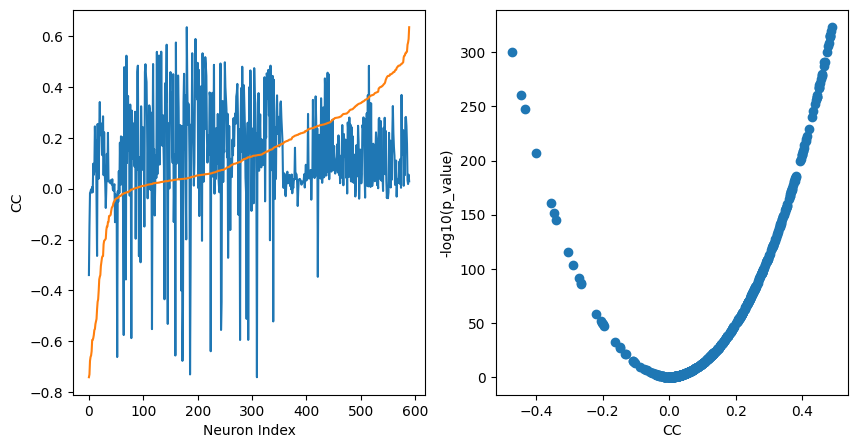

In [143]:
from scipy import stats

l = []

for index in range(combine_spikes_matrix_all.shape[1]):
    # use scipy state to get p_value
    cc, p_value = stats.pearsonr(bpm[:], combine_spikes_matrix_all[:, index])

    l.append((cc, p_value))
    if index % 100 == 0:
        print(index)
    # plt.scatter(bpm_camera, combine_spikes_matrix_all[:, index])
    # plt.xlabel('BPM')
    # plt.ylabel('Spike Rate')
    # plt.title(f"BPM vs Spike Rate - Neuron {index}, CC = {cc:.2f}")
    # plt.show()
l = np.array(l)
print(l.shape)
cc_list = l[:, 0]
p_value_list = l[:, 1]
plt.subplots(1, 2, figsize=(10, 5))
plt.subplot(121)
plt.plot(cc_list)
plt.xlabel('Neuron Index')
plt.ylabel('CC')
cc_sorted = np.sort(cc_list)
plt.plot(cc_sorted)
plt.xlabel('Neuron Index')
plt.ylabel('CC')

p_log10 = -np.log10(p_value)
np.nan_to_num(p_log10, copy=False, nan=p_log10.max())
plt.subplot(122)
plt.scatter(cc_list, -np.log10(p_value_list))
plt.xlabel('CC')
plt.ylabel('-log10(p_value)')


In [146]:
top_k = 10
print(f"Top {top_k} high correlation neurons: ", np.argsort(cc_list)[::-1][:top_k])
print(f"Top {top_k} low correlation neurons: ", np.argsort(cc_list)[:top_k])

Top 10 high correlation neurons:  [180 196 160 143 133 125 190 209 129  69]
Top 10 low correlation neurons:  [309 186 172  52 159 224 278 293  78  64]


Text(0.5, 1.0, 'BPM vs Spike Rate - Neuron 125(CENT2), CC = 0.54')

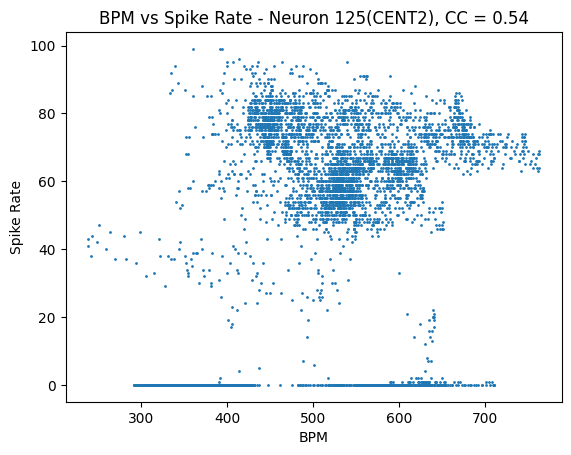

In [158]:
index = 125
cc = np.corrcoef(bpm, combine_spikes_matrix_all[:, index])[0, 1]
plt.scatter(bpm, combine_spikes_matrix_all[:, index], s = 1)
plt.xlabel('BPM')
plt.ylabel('Spike Rate')
plt.title(f"BPM vs Spike Rate - Neuron {index}({results['cluster_region'][index]}), CC = {cc:.2f}")

In [160]:
top_cc_index = np.argsort(cc_list)[::-1][:50]
for index in top_cc_index:
    region = results['cluster_region'][index]
    print(index, f"{cc_list[index]:.2f}", region)

180 0.64 CENT2
196 0.59 CENT2
160 0.58 CENT2
143 0.57 CENT2
133 0.54 CENT2
125 0.54 CENT2
190 0.53 CENT2
209 0.53 CENT2
129 0.52 CENT2
69 0.52 arb
214 0.52 CENT2
250 0.50 CENT2
200 0.50 CENT2
242 0.49 CENT2
118 0.49 CENT2
104 0.49 CENT2
230 0.49 CENT2
215 0.48 CENT2
334 0.48 PAG
90 0.48 arb
515 0.48 CA3
282 0.48 CENT2
65 0.48 arb
304 0.47 PAG
202 0.47 CENT2
330 0.47 PAG
297 0.47 CENT2
89 0.46 arb
103 0.46 CENT2
150 0.46 CENT2
439 0.46 SCdg
327 0.45 PAG
175 0.45 CENT2
155 0.45 CENT2
441 0.45 SCdg
131 0.45 CENT2
164 0.45 CENT2
216 0.44 CENT2
338 0.44 PAG
105 0.44 CENT2
328 0.44 PAG
323 0.44 PAG
434 0.43 SCdg
340 0.43 PAG
106 0.42 CENT2
140 0.41 CENT2
273 0.41 CENT2
197 0.41 CENT2
285 0.41 CENT2
141 0.41 CENT2
